In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import os
os.chdir('/content/drive/MyDrive/credit-risk-assessment-system')

import pandas as pd
import numpy as np
import joblib

X_train = pd.read_csv('data/processed/X_train_fe.csv')
X_test = pd.read_csv('data/processed/X_test_fe.csv')
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()

leftover_cols = [c for c in ['SK_ID_CURR', 'AMT_ANNUITY_RAW', 'AMT_CREDIT_RAW', 'AMT_INCOME_TOTAL_RAW']
                  if c in X_train.columns]
X_train_model = X_train.drop(columns=leftover_cols)
X_test_model = X_test.drop(columns=leftover_cols)

catboost_weighted = joblib.load('models/catboost_weighted_final.pkl')
print("Model loaded:", X_train_model.shape, X_test_model.shape)

Model loaded: (246008, 191) (61503, 191)


In [13]:
!pip install shap -q

In [14]:
import shap

explainer = shap.TreeExplainer(catboost_weighted)

sample_size = 1000
X_sample = X_test_model.sample(n=sample_size, random_state=42)

shap_values = explainer.shap_values(X_sample)

print(shap_values.shape)

(1000, 191)


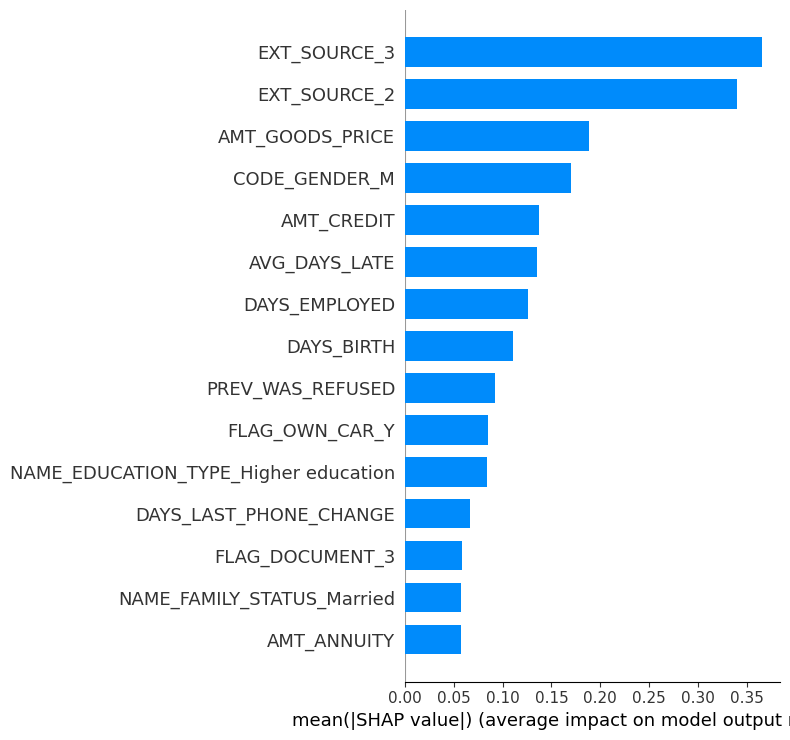

In [15]:
shap.summary_plot(shap_values, X_sample, plot_type='bar', max_display=15)

Predicted probability: 0.4086473436347045


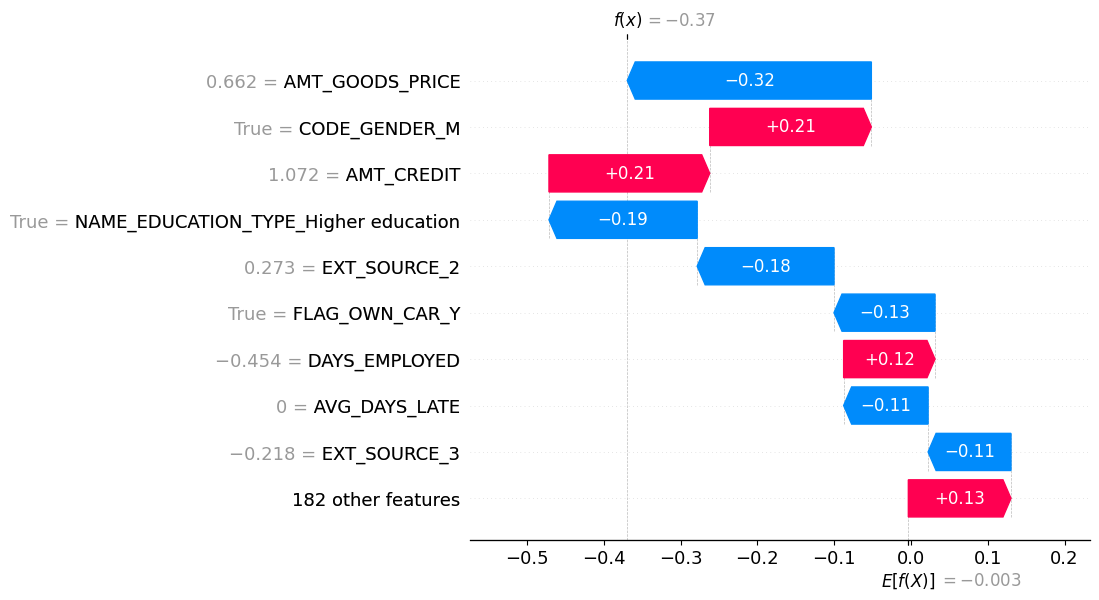

In [16]:
idx = 0  # first applicant in the sample
applicant_shap = shap_values[idx]
applicant_data = X_sample.iloc[idx]

print("Predicted probability:", catboost_weighted.predict_proba(X_sample.iloc[[idx]])[:, 1][0])

shap.plots.waterfall(
    shap.Explanation(
        values=applicant_shap,
        base_values=explainer.expected_value,
        data=applicant_data.values,
        feature_names=X_sample.columns.tolist()
    ),
    max_display=10
)

The gender fairness check

In [17]:
X_test_with_gender = X_test_model.copy()
X_test_with_gender['predicted_proba'] = catboost_weighted.predict_proba(X_test_model)[:, 1]

male_mask = X_test_with_gender['CODE_GENDER_M'] == 1
print("Mean predicted default probability:")
print(f"  Male applicants:   {X_test_with_gender.loc[male_mask, 'predicted_proba'].mean():.4f}")
print(f"  Female applicants: {X_test_with_gender.loc[~male_mask, 'predicted_proba'].mean():.4f}")

print("\nActual default rate (ground truth, for comparison):")
print(f"  Male applicants:   {y_test[male_mask.values].mean():.4f}")
print(f"  Female applicants: {y_test[~male_mask.values].mean():.4f}")

Mean predicted default probability:
  Male applicants:   0.4587
  Female applicants: 0.3762

Actual default rate (ground truth, for comparison):
  Male applicants:   0.1017
  Female applicants: 0.0699


In [18]:
gender_col_idx = X_sample.columns.get_loc('CODE_GENDER_M')
gender_shap_values = shap_values[:, gender_col_idx]

print("Average SHAP contribution from CODE_GENDER_M:")
print(f"  Overall mean: {gender_shap_values.mean():.4f}")
print(f"  Mean when Male:   {gender_shap_values[X_sample['CODE_GENDER_M'] == 1].mean():.4f}")
print(f"  Mean when Female: {gender_shap_values[X_sample['CODE_GENDER_M'] == 0].mean():.4f}")

Average SHAP contribution from CODE_GENDER_M:
  Overall mean: -0.0314
  Mean when Male:   0.2271
  Mean when Female: -0.1454


Retrain excluding gender, measure the cost

In [19]:
gender_cols = [c for c in X_train_model.columns if 'GENDER' in c]
print("Dropping:", gender_cols)

X_train_fair = X_train_model.drop(columns=gender_cols)
X_test_fair = X_test_model.drop(columns=gender_cols)

best_params = {
    'iterations': 477, 'depth': 7, 'learning_rate': 0.042106168367021204,
    'l2_leaf_reg': 7.2626141545771805, 'random_state': 42, 'verbose': 0,
    'auto_class_weights': 'Balanced'
}

from catboost import CatBoostClassifier
catboost_fair = CatBoostClassifier(**best_params)
catboost_fair.fit(X_train_fair, y_train)

y_pred_proba_fair = catboost_fair.predict_proba(X_test_fair)[:, 1]
auc_fair = roc_auc_score(y_test, y_pred_proba_fair)
print(f"AUC without gender: {auc_fair:.4f}  (with gender was: 0.7635)")

Dropping: ['CODE_GENDER_M', 'CODE_GENDER_XNA']
AUC without gender: 0.7604  (with gender was: 0.7635)


In [20]:
import joblib

joblib.dump(catboost_fair, 'models/catboost_final_fair.pkl')

y_pred_fair_default = (catboost_fair.predict_proba(X_test_fair)[:, 1] >= 0.5).astype(int)
print("Fair model at 0.5 threshold:")
print(classification_report(y_test, y_pred_fair_default))

print("Saved fair model")

Fair model at 0.5 threshold:
              precision    recall  f1-score   support

           0       0.96      0.72      0.82     56538
           1       0.17      0.67      0.27      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.69      0.55     61503
weighted avg       0.90      0.71      0.78     61503

Saved fair model


In [21]:
from sklearn.metrics import precision_recall_curve

precisions_fair, recalls_fair, thresholds_fair = precision_recall_curve(y_test, y_pred_proba_fair)

diffs_fair = np.abs(precisions_fair[:-1] - recalls_fair[:-1])
optimal_idx_fair = np.argmin(diffs_fair)
optimal_threshold_fair = thresholds_fair[optimal_idx_fair]

print(f"Optimal threshold: {optimal_threshold_fair:.4f}")
print(f"Precision: {precisions_fair[optimal_idx_fair]:.4f}")
print(f"Recall: {recalls_fair[optimal_idx_fair]:.4f}")

y_pred_optimal_fair = (y_pred_proba_fair >= optimal_threshold_fair).astype(int)
print("\nClassification report at optimal threshold:")
print(classification_report(y_test, y_pred_optimal_fair))

Optimal threshold: 0.7199
Precision: 0.2961
Recall: 0.2961

Classification report at optimal threshold:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94     56538
           1       0.30      0.30      0.30      4965

    accuracy                           0.89     61503
   macro avg       0.62      0.62      0.62     61503
weighted avg       0.89      0.89      0.89     61503



In [22]:
import json

decision_config_fair = {
    'optimal_threshold': float(optimal_threshold_fair),
    'precision_at_threshold': float(precisions_fair[optimal_idx_fair]),
    'recall_at_threshold': float(recalls_fair[optimal_idx_fair]),
    'features_excluded_for_fairness': gender_cols,
    'auc': float(auc_fair)
}

with open('models/decision_threshold_final.json', 'w') as f:
    json.dump(decision_config_fair, f, indent=2)

print("Saved final decision config")
print(decision_config_fair)

Saved final decision config
{'optimal_threshold': 0.7198832270177709, 'precision_at_threshold': 0.29607250755287007, 'recall_at_threshold': 0.29607250755287007, 'features_excluded_for_fairness': ['CODE_GENDER_M', 'CODE_GENDER_XNA'], 'auc': 0.760375402945312}
